# Maze Solver

A **maze** is a rectangular array of cells. The **agent** may move across the cells of the mase. By stepping into a cell, the agent receives a reward (or pays a penalty). Some cells are **terminal**, when stepping into a terminal cell the agent finishes the game (exits the maze). The **goal** of the agent is to maximize the total cummulative reward (minimize the total cummulative loss).

In addition to **regular** and **terminal** cells, there are also **walls**: walls are forbidden areas of the maze. The agent canot step onto a wall cell.

<div class="alert alert-block alert-info">
<b>The Assignment:</b>
Implement the maze environment and develop optimal decision policy for moving across the maze.
</div>

## Basic Imports

In [ ]:
from abc import ABC, abstractmethod
from typing import Iterable, Callable
from copy import copy

import numpy as np
import matplotlib.pyplot as plt

from random import random, choices, randint, sample

## The Maze

Let us implement the maze first, so that later we can implement solution algorithm(s).

We will start by implementing individual cells, and the we will collect them all within a single maze board.

### Implementing Individual Cells

In [ ]:
class Cell(ABC):
    """Abstract base class for all maze cells."""

    @abstractmethod
    def get_reward(self) -> float:
        """The reward an agent receives when stepping onto this cell."""
        pass

    def is_steppable(self) -> bool:
        """Checks if an agent can step onto this cell.

        Regular, terminal and TELEPORT cells are steppable.
        Walls are not steppable.
        """
        return True

    def is_terminal(self) -> bool:
        """Checks if the cell is terminal.

        When stepping onto a terminal cell the agent exits
        the maze and finishes the game.
        """
        return False

    def has_value(self) -> bool:
        """Check if the cell has value.

        The value is defined for regular cells and terminal cells,
        but not for walls.
        """
        return True

We will use the `Cell` class to derive all other cell classes. Please note that it may seem that `is_steppable` and `has_value` are essentially synonims, but this is not true in general.

Consider for example **teleport cells**. When stepping onto such a cell the agent is instantinuously transported into another, linked cell. Such a cell is different from the cell to which it is linked. It has a distinct geometrical location, and is steppable. However, from routing point of view it is just an alias for the linked cell, and so there is no reason for it to have a distinct value.

Let us now implement some basic types of cells:

In [ ]:
class RegularCell(Cell):
    """A common, non-terminal, steppable cell."""

    def __init__(self, reward: float):
        self.reward = reward

    def get_reward(self) -> float:
        return self.reward


class TerminalCell(Cell):
    """A terminal cell."""

    def __init__(self, reward: float):
        self.reward = reward

    def get_reward(self) -> float:
        return self.reward

    def is_terminal(self) -> bool:
        return True

    def has_value(self) -> bool:
        return False


class WallCell(Cell):
    """A non-steppable cell."""

    def get_reward(self) -> float:
        return 0

    def is_steppable(self) -> bool:
        return False

    def has_value(self) -> bool:
        return False


class TeleportCell(Cell):
    """A teleport cell that teleports the agent to another position (row, col)."""

    def __init__(self, reward: float, target_position: tuple[int, int]):
        """
        :param reward: Reward for stepping into the teleport cell.
        :param target_position: Tuple (row, col) to teleport to.
        """
        self.reward = reward
        self.target_row, self.target_col = target_position

    def get_reward(self) -> float:
        return self.reward

    def get_target_position(self) -> tuple[int, int]:
        """
        Returns the target position to teleport to in (row, col) format.
        """
        return (self.target_row, self.target_col)


### Implementing the Maze Board

The maze board is essentially a rectangular grid of cells. The board is not concerned with the type of individual cells, it is only interested in their relative arrangement.

In [ ]:
class MazeBoard:
    """Rectangular grid of cells representing a single mase."""

    @staticmethod
    def validate_cells(cells: Iterable[Iterable[Cell]]) -> tuple[int, int, list[list[Cell]]]:
        """
        Utility function used to validate the given double-iterable of of cells.

        Returns: tuple[int, int, list[list[Cell]]]
            int: number of rows
            int: number of columns
            list[list[Cell]]: double-list of cells from the input iterable
        """
        cells = [list(row) for row in cells] if cells else []
        if not cells:
            raise Exception("Number of rows in a board must be at least one.")
        if not cells[0]:
            raise Exception("There has to be at least one column.")
        rows_no = len(cells)
        cols_no = len(cells[0])
        for row in cells:
            if not row or len(row) != cols_no:
                raise Exception(
                    "Each row in a a board must have the same number of columns. ")
        return rows_no, cols_no, cells

    def __init__(self, cells: Iterable[Iterable[Cell]]):
        """
        Initialize the maze board from the given `cells`.

        The input double-iterable of cells is such that the elements of the outer
        iterable are considered to be rows. The input cells must satisfy certain
        conditions in order to be considered valid:

        * There must be at least one row.
        * All rows must be of the same length, which is at least one.
        """
        rows_no, cols_no, cells = MazeBoard.validate_cells(cells)
        self.cells = cells
        self.rows_no = rows_no
        self.cols_no = cols_no

    def __getitem__(self, key: tuple[int, int]) -> Cell:
        """Return cell in the given row and column."""
        r, c = key
        return self.cells[r][c]


### Creating and Visualizing Maze Boards

It would be nice to be able to randomly generate maze boards, and also to visualize them. It will enable us to effectively test our algorithms.

Let us first create a method for randomly generating boards. We will define this method to be very generic, allowing for different kind of cells to be generated with different probability.

In [ ]:
# Type-hint used to indicate a function which, when invoked, generates a cell.
CellGenerator = Callable[[], Cell]

def create_random_board(size: tuple[int, int], specs=list[tuple[float, CellGenerator]]) -> MazeBoard:
    """
    Generate a random cell.

    Args:
        size (float): Board size: height and width.
        specs (list[tuple[float, CellGenerator]]):
            List of tuples, each of which contains a weight factor and a Cell-generating function
            The weight-factor is proportional to the probability with thich the Cell-generator
            function will be invoked.
    """
    h, w = size
    weights = [w for w, _ in specs]
    generators = [g for _, g in specs]
    # The line below is a bit tricky...
    # `random_cell` is a function which returns a random cell once it has been invoked.
    # `choices` function returns a list of elements taken from `generators` with probabilities
    #    proportional to `weights`. The length of such list is set to 1. Therefore by indexing
    #    with `[0]` we are actually requiesting for the first and only element of that list.
    # In this way we obtained one such randomly selected generator.
    # We need to invoke it with `()` in order to actually get a cell.
    random_cell = lambda: choices(generators, weights, k=1)[0]()
    cells = [[random_cell() for i in range(w)] for j in range(h)]
    return MazeBoard(cells)

Let us furhter define a function that will help us visualize maze boards.

In [ ]:
def default_cell_color(cell: Cell) -> tuple[int, int, int]:
    if isinstance(cell, TeleportCell):
        return (128, 0, 128)  # Teleport cell (PURPLE)
    elif isinstance(cell, RegularCell):
        if cell.get_reward() == -1:
            return (255, 255, 255)  # Regular cell (WHITE)
        else:
            return (255, 0, 0)  # Regular cell with penalty (RED)
    elif isinstance(cell, WallCell):
        return (0, 0, 0)  # Wall cell (BLACK)
    else:
        return (0, 0, 255)  # Terminal cell (BLUE)

def draw_board(board: MazeBoard, color = default_cell_color, pos: tuple[int, int] = None, ax=None):
    ax = ax if ax is not None else plt
    board_img = np.ones(shape=(board.rows_no, board.cols_no, 3), dtype=np.uint8)
    for i in range(board.rows_no):
        for j in range(board.cols_no):
            board_img[i, j, :] = color(board[i, j])
    if pos is not None:
        row, col = pos
        ax.text(col-0.1, row+0.1, "X", fontweight="bold")
    if ax is not None:
        ax.imshow(board_img)
    else:
        plt.imshow(board_img)

### Testing Maze Board Generation and Visualization

In [ ]:
# This will be used as the default specification for the generator...
# It requires that the reqular cells with reward -1 are 7 times more likely than
# regular cells with higher penalty, walls and terminal cells.

DEFAULT_SPECS = [
    (10, lambda: RegularCell(-1)),
    (2, lambda: RegularCell(-10)),
    (2, lambda: WallCell()),
    (1, lambda: TerminalCell(-1))
]

In [ ]:
def add_random_teleports(board, num_pairs=2, cost=-1):
    """Adds `num_pairs` teleport cells to the board at random positions."""
    all_positions = [
        (r, c) for r in range(board.rows_no)
        for c in range(board.cols_no)
        if not isinstance(board[r, c], WallCell)
    ]

    if len(all_positions) < num_pairs * 2:
        raise ValueError("Not enough usable cells for teleport pairs.")

    selected = sample(all_positions, num_pairs * 2)
    pairs = list(zip(selected[:num_pairs], selected[num_pairs:]))

    for from_pos, to_pos in pairs:
        from_r, from_c = from_pos
        to_r, to_c = to_pos

        board.cells[from_r][from_c] = TeleportCell(cost, (to_r, to_c))

    return pairs



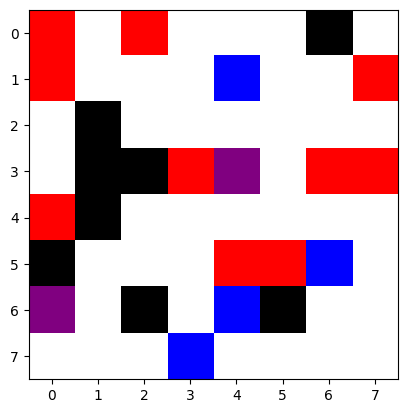

In [ ]:
board = create_random_board(size=(8, 8), specs=DEFAULT_SPECS)
pairs = add_random_teleports(board)
draw_board(board)

### Maze as an MDP Environment

We will now wrap the maze board within a MDP environment which we will be used within our Dynamic Programming procedure.

In [ ]:
# Let us first enumerate the possible actions for better readability.
RIGHT = 0
UP = 1
LEFT = 2
DOWN = 3

# The following lus is used only to provide human-readable form of each action
ACTIONS = ["RIGHT", "UP", "LEFT", "DOWN"]

In [ ]:
class MazeEnvironment:
    """Wrapper for a maze board that behaves like an MDP environment.

    This is a callable object that behaves like a deterministic MDP state
    transition function: given the current state and action, it returns the
    following state and reward.

    In addition, the environment object is capable of enumerating all possible
    states and all possible actions. For a given state it is also capable of
    deciding if the state is terminal or not.
    """

    def __init__(self, board: MazeBoard):
        """Initialize the enviornment by specifying the underlying maze board."""
        self.board = board

    def validate_position(self, row, col):
        """A utility function that validates a position."""
        if row < 0 or row >= self.rows_no:
            raise Exception("Invalid row position.")
        if col < 0 or col >= self.cols_no:
            raise Exception("Invalid column position.")
        if not self.board[row, col].is_steppable():
            raise Exception("Invalid position: unsteppable cell.")
        return row, col

    def move_up_from(self, row: int, col: int) -> tuple[int, int]:
        if row != 0 and self.board[row-1, col].is_steppable():
            return row-1, col
        else:
            return row, col

    def move_down_from(self, row: int, col: int) -> tuple[int, int]:
        if row != self.board.rows_no-1 and self.board[row+1, col].is_steppable():
            return row+1, col
        else:
            return row, col

    def move_left_from(self, row: int, col: int) -> tuple[int, int]:
        if col != 0 and self.board[row, col-1].is_steppable():
            return row, col-1
        else:
            return row, col

    def move_right_from(self, row: int, col: int) -> tuple[int, int]:
        if col != self.board.cols_no-1 and self.board[row, col+1].is_steppable():
            return row, col+1
        else:
            return row, col

    def move_from(self, row: int, col: int, action: int) -> tuple[int, int]:
        if action == RIGHT:
            return self.move_right_from(row, col)
        elif action == UP:
            return self.move_up_from(row, col)
        elif action == LEFT:
            return self.move_left_from(row, col)
        elif action == DOWN:
            return self.move_down_from(row, col)
        else:
            raise Exception("Invalid direction.")


    def __call__(self, state: tuple[int, int], action: int) -> tuple[tuple[int, int], float, bool]:
        row, col = state
        start_cell = self.board[row, col]

        # If we start on a teleport cell -> teleport immediately and do not apply the action
        if isinstance(start_cell, TeleportCell):
            to_row, to_col, dest_cell = self.resolve_teleport(row, col)
            reward = start_cell.get_reward()
            is_terminal = start_cell.is_terminal()
            return (to_row, to_col), reward, is_terminal

        # Otherwise apply the action normally
        new_row, new_col = self.move_from(row, col, action)
        landing_cell = self.board[new_row, new_col]

        # If we landed on a teleport -> teleport and return the teleport cell's reward
        if isinstance(landing_cell, TeleportCell):
            to_row, to_col, dest_cell = self.resolve_teleport(new_row, new_col)
            reward = landing_cell.get_reward()
            is_terminal = landing_cell.is_terminal()
            return (to_row, to_col), reward, is_terminal

        # No teleport
        reward = landing_cell.get_reward()
        is_terminal = landing_cell.is_terminal()
        return (new_row, new_col), reward, is_terminal

    def resolve_teleport(self, row, col):
        """
        If the cell at (row, col) is a TeleportCell and its target is steppable,
        teleport the agent. This also handles chained teleports.
        """
        cell = self.board[row, col]
        while isinstance(cell, TeleportCell):
            target_row, target_col = cell.get_target_position()
            target_cell = self.board[target_row, target_col]
            if not target_cell.is_steppable():
                break
            row, col = target_row, target_col
            cell = target_cell
        return row, col, cell


    def get_states(self):
        states = []
        for r in range(self.board.rows_no):
            for c in range(self.board.cols_no):
                if self.board[r, c].is_steppable():
                    states.append((r, c))
        return states

    def is_terminal(self, s):
        return self.board[s[0], s[1]].is_terminal()

    def get_actions(self):
        return [RIGHT, UP, LEFT, DOWN]

Let us test the MDP environment. This will also enable us to understand better the manner in which the environment object is intended to be used.

### Testing the Maze Environment

Let us test the environment by issuing several commands and observing the result.

In [ ]:
env = MazeEnvironment(board)

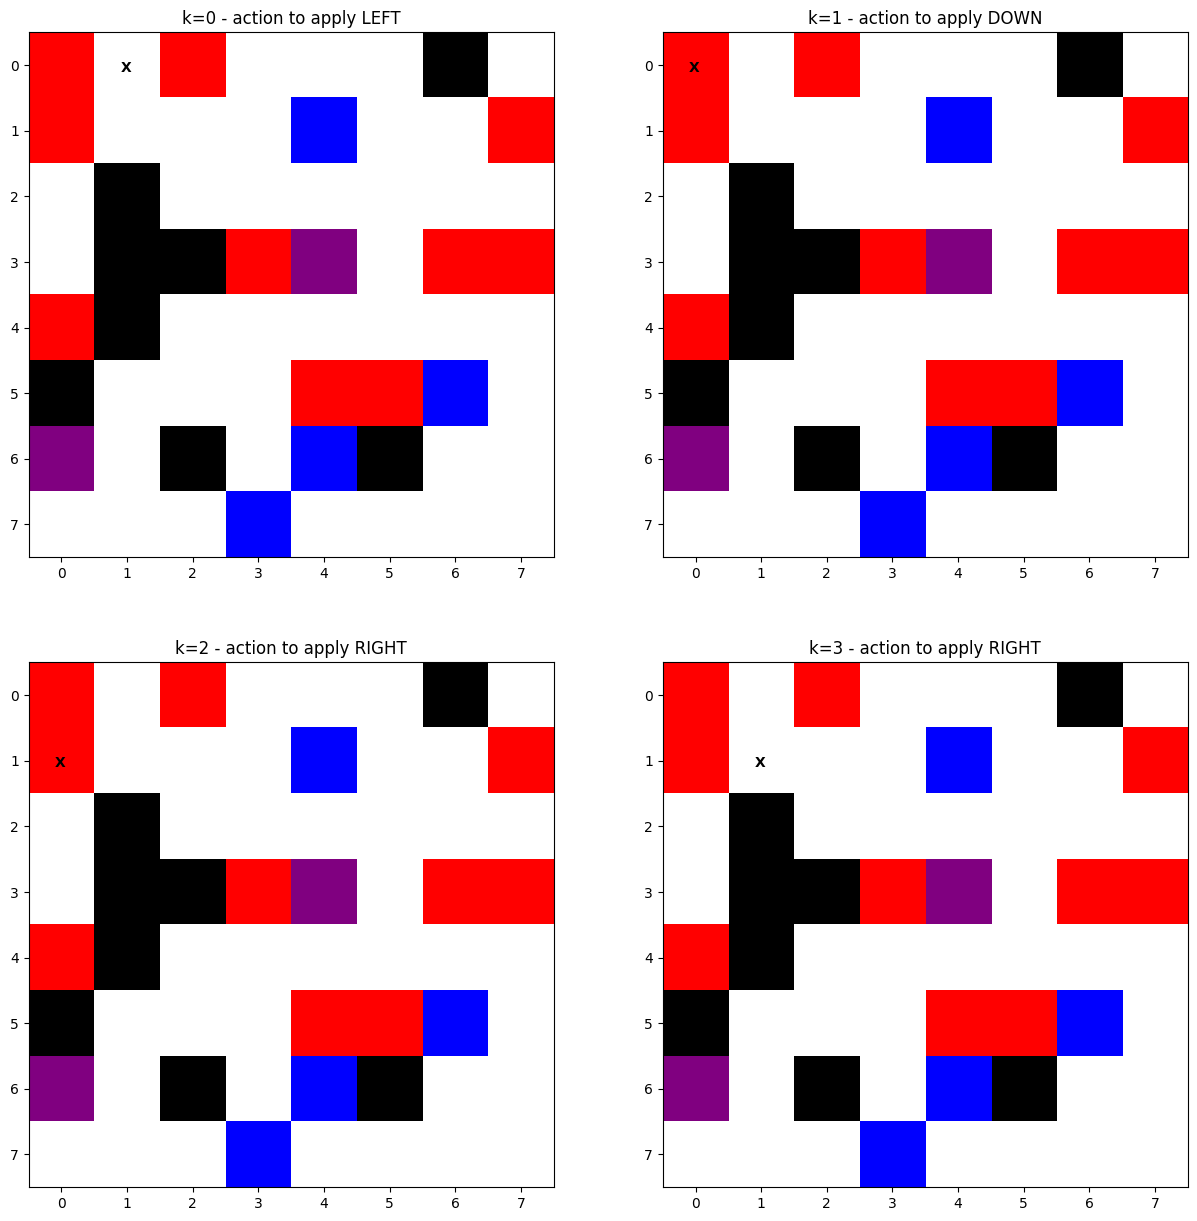

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 15))
axes = axes.flatten()
axes
state = (0, 1)
actions = [LEFT, DOWN, RIGHT, RIGHT]
for k, (a, ax) in enumerate(zip(actions, axes)):
    ax.set_title(f"k={k} - action to apply {ACTIONS[a]}")
    draw_board(board, pos=state, ax=ax)
    state, reward, terminal = env(state, a)

Testing the teleportation

In [ ]:
def get_any_teleport_cell(board):
    nrows = board.rows_no
    ncols = board.cols_no
    for r in range(nrows):
        for c in range(ncols):
            cell = board[r, c]
            if isinstance(cell, TeleportCell):
                return (r, c), cell.get_target_position()
    return None, None


Teleportation: from (3, 4) to (0, 2)


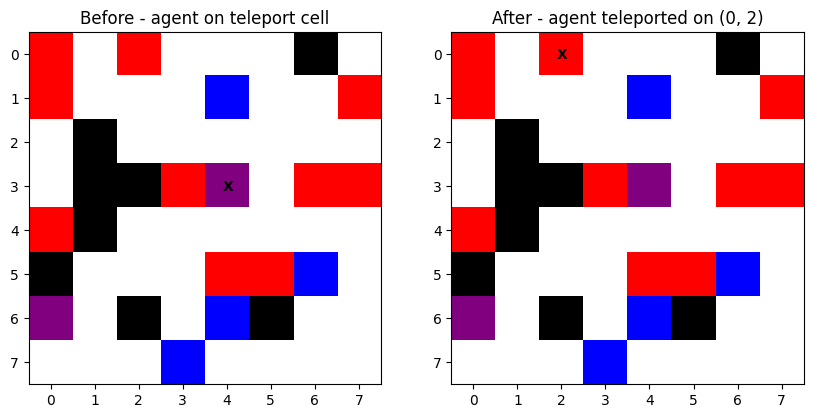

In [ ]:
teleport_pos, teleport_target = get_any_teleport_cell(board)

if teleport_pos is None:
    print("There are no teleport cells on the board!")
else:
    print(f"Teleportation: from {teleport_pos} to {teleport_target}")

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    axes = axes.flatten()

    axes[0].set_title("Before - agent on teleport cell")
    draw_board(board, pos=teleport_pos, ax=axes[0])


    action = RIGHT
    next_state, reward, terminal = env(teleport_pos, action)

    # After teleportation
    axes[1].set_title(f"After - agent teleported on {next_state}")
    draw_board(board, pos=next_state, ax=axes[1])


## Value Iteration Algorithm

Let us now implement the **asynchronous version** of the **VALUE ITERATION ALGORITHM**. This algorithm will enable us to compute optimal state values for each state.

In [ ]:
def update_state_value(env: MazeEnvironment, s, v, gamma):
    """Update value of the given state.

    Args:
        env (MazeEnvironment): The environment to work on.
        s : The state (cell position).
        v : Values of other states.
        gamma : discount factor.
    """
    rhs = []
    for a in env.get_actions():
        s_new, r, _ = env(s, a)
        rhs.append(r + gamma*v[s_new])
    return max(rhs)

In [ ]:
def async_update_all_values(env: MazeEnvironment, v, gamma):
    """Update values of all states.

    Args:
        env (MazeEnvironment): The environment to work on.
        v : Values of other states.
        gamma : discount factor.
    """
    for s in env.get_states():
        if not env.is_terminal(s):
            v[s] = update_state_value(env, s, v, gamma)
    return copy(v)

In [ ]:
def init_values(env):
    """Randomly initialize states of the given environment."""
    values = {s: -10*random() for s in env.get_states()}

    for s in values:
        if env.is_terminal(s):
            values[s] = 0

    return values

It is also convenient to have a method for visualization of values.

In [ ]:
def draw_teleports(board, ax):
    for r in range(board.rows_no):
        for c in range(board.cols_no):
            cell = board[r, c]
            if isinstance(cell, TeleportCell):
                tr, tc = cell.get_target_position()
                # Center of the current and target cells
                x1, y1 = c + 0.5, r + 0.5
                x2, y2 = tc + 0.5, tr + 0.5

                ax.annotate("",
                            xy=(x2, y2), xycoords='data',
                            xytext=(x1, y1), textcoords='data',
                            arrowprops=dict(arrowstyle="->", color="magenta", lw=2))


In [ ]:
def draw_values(env, values, ax=None):
    ax = ax if ax is not None else plt
    draw_board(env.board, ax=ax)
    draw_teleports(env.board, ax=ax)
    for s in values:
        ax.text(s[1]-0.25, s[0]+0.1, f"{values[s]:.1f}")

Let us test the above methods by visualizing initial state values, and also the evolution of state values through several initial steps.

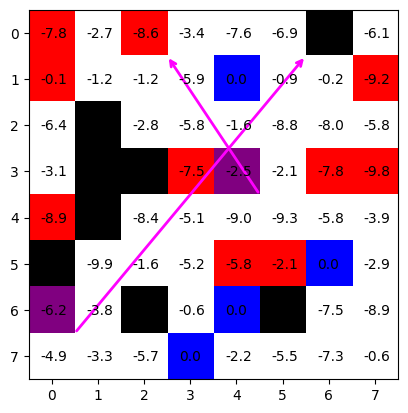

In [ ]:
values = init_values(env)
draw_values(env, values)

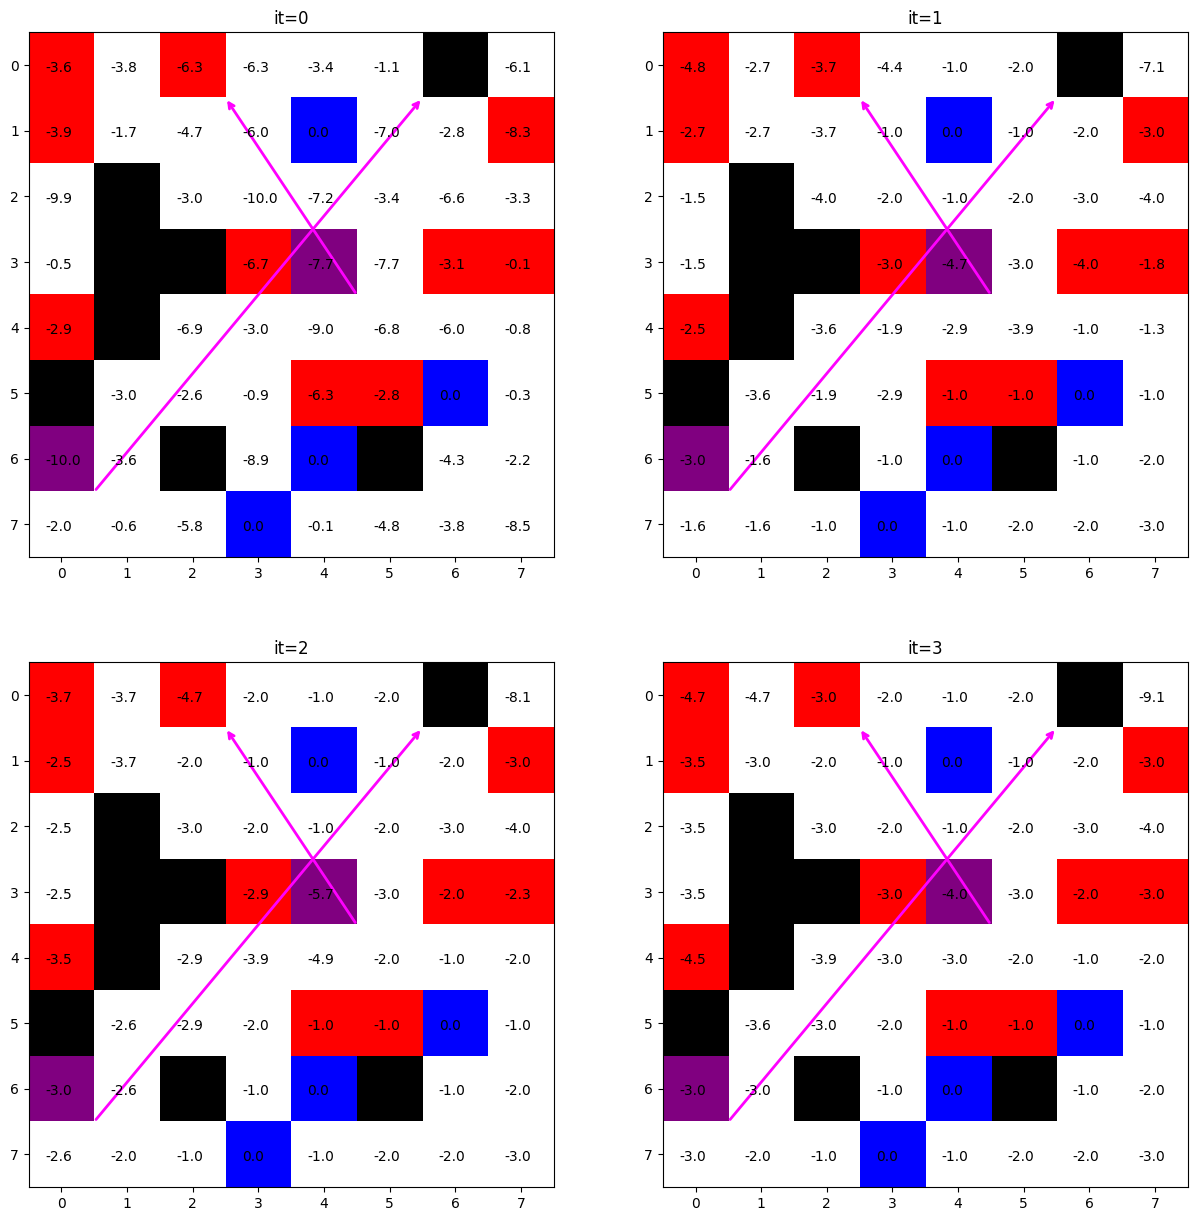

In [ ]:
nrows, ncols = 2, 2
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 15))
axes = axes.flatten()
values = init_values(env)
for k in range(nrows*ncols):
    draw_values(env, values, ax)
    axes[k].set_title(f"it={k}")
    draw_values(env, values, ax=axes[k])
    values = async_update_all_values(env, values, 1.0)

We are finally ready to implement the value iteration algorithm.

In [ ]:
def value_iteration(env, gamma, eps, v0=None, maxiter=100):
    v = v0 if v0 is not None else init_values(env)
    for k in range(maxiter):
        nv = async_update_all_values(env, v, gamma)
        err = max([abs(nv[s] - v[s]) for s in v])
        if err<eps:
            return nv, k
        v = nv
    return v, k

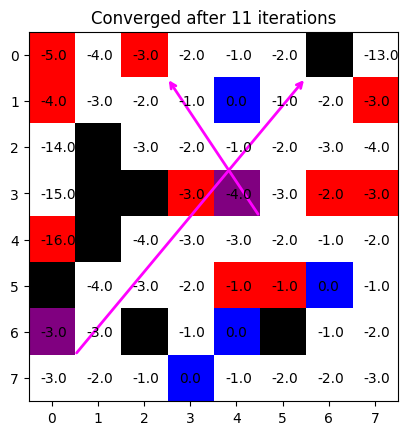

In [ ]:
fin_v, k = value_iteration(env, 1.0, 0.01)
draw_values(env, fin_v)
plt.title(f"Converged after {k} iterations");

##Value iteration using Q-function

In [ ]:
def q_value_iteration(env, gamma, eps, q0=None, maxiter=100):
    actions = env.get_actions()
    states = env.get_states()

    # Initialize Q(s,a)
    if q0 is not None:
        q = q0.copy()
    else:
        q = {(s, a): 0.0 for s in states for a in actions}

    for k in range(maxiter):
        q_new = q.copy()
        delta = 0

        for s in states:
            if env.is_terminal(s):
                for a in actions:
                    q_new[(s, a)] = 0.0
                continue

            for a in actions:
                next_state, reward, done = env(s, a)
                max_q_next = max(q[(next_state, a2)] for a2 in actions)
                q_old = q[(s, a)]
                q_new[(s, a)] = reward + gamma * max_q_next
                delta = max(delta, abs(q_old - q_new[(s, a)]))

        q = q_new
        if delta < eps:
            return q, k + 1

    return q, maxiter

In [ ]:
def extract_policy_from_q(Q, env):
    policy = {}
    actions = env.get_actions()

    for s in env.get_states():
        if env.is_terminal(s):
            policy[s] = None
        else:
            best_action = max(actions, key=lambda a: Q[(s, a)])
            policy[s] = best_action

    return policy

In [ ]:
def simulate_policy(env, policy, start_state, max_steps=100):
    state = start_state
    for step in range(max_steps):
        if env.is_terminal(state):
            return step  # number of steps to reach the terminal
        action = policy[state]
        if action is None:
            return step
        state, _, _ = env(state, action)
    return max_steps  # did not reach terminal within max_steps steps

Converged after 18 iterations.
Agent reached terminal cell in 5 steps from (0, 0).


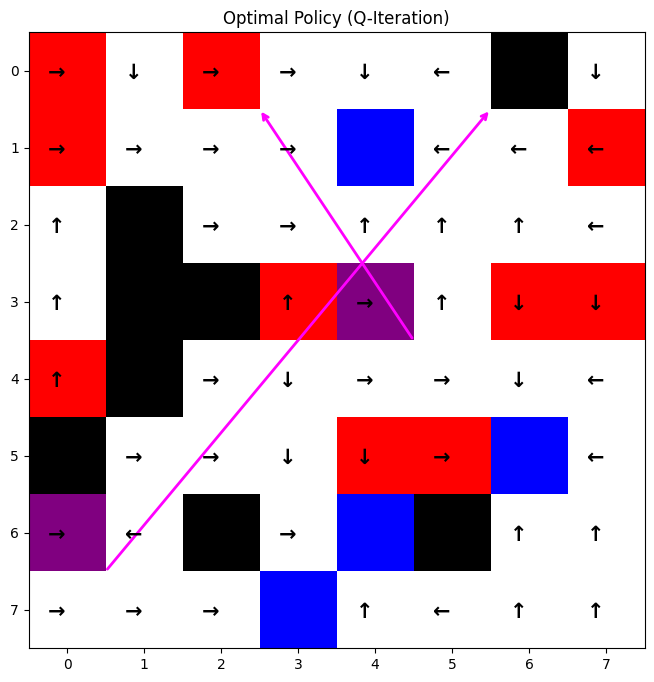

In [ ]:
# level 1 Helper Functions

def action_symbol(a):
    if a == 0: # RIGHT
        return "→"
    elif a == 1: # UP
        return "↑"
    elif a == 2: # LEFT
        return "←"
    elif a == 3: # DOWN
        return "↓"
    else:
        return "?"

def draw_policy(env, policy, ax=None):
    ax = ax if ax is not None else plt.gca()
    draw_board(env.board, ax=ax)
    # Add teleport arrows if they exist
    draw_teleports(env.board, ax=ax)
    for s, a in policy.items():
        if a is not None:
            ax.text(s[1]-0.25, s[0]+0.1, action_symbol(a), fontsize=15, fontweight='bold', color='black')

# level 1 Execution

gamma = 1.0
eps = 0.01
maxiter = 100

# 1. Run Q-Value Iteration
final_q, num_iters = q_value_iteration(env, gamma, eps, maxiter=maxiter)
print(f"Converged after {num_iters} iterations.")

# 2. Extract optimal policy from Q-values
optimal_policy_map = extract_policy_from_q(final_q, env)

# 3. Find a valid start state (not a wall and not terminal)
all_steppable_states = [s for s in env.get_states() if not env.is_terminal(s)]

if all_steppable_states:
    # Logic to find a safe start state
    agent_start_pos = all_steppable_states[0]

    # 4. Simulate the agent movement
    steps_count = simulate_policy(env, optimal_policy_map, agent_start_pos)
    print(f"Agent reached terminal cell in {steps_count} steps from {agent_start_pos}.")

    # 5. Visualization
    plt.figure(figsize=(8, 8))
    draw_policy(env, optimal_policy_map)
    plt.title("Optimal Policy (Q-Iteration)")
    plt.show()
else:
    print("No valid steppable states found.")

Optimal policy - using Q-function

Let us test the algorithm by

## Finding and Visualizing Optimal Decision Policy

Let us first define a function that computes a greedy action (with respect to the given state values) for a specific given state.

In [ ]:
def greedy_action(env, s, v, gamma):
    vs = []
    for a in env.get_actions():
        s_next, r, _ = env(s, a)
        vs.append(r + gamma*v[s_next])
    return np.argmax(vs)

Let us test it to see if we are getting the expected result. Notice that our function will return just a single action, even if there are more than one possibility.

In [ ]:
aopt = greedy_action(env, (5, 4), fin_v, 1.0)
ACTIONS[aopt]

'DOWN'

We can now compute the full optimal policy

In [ ]:
def optimal_policy(env, v, gamma):
    return {s: greedy_action(env, s, v, gamma) for s in env.get_states() if not env.is_terminal(s)}

It is also helpfull to have a function for visualization of policies.

In [ ]:
def action_symbol(a):
    if a == RIGHT:
        return "→"
    elif a==UP:
        return "↑"
    elif a==LEFT:
        return "←"
    elif a == DOWN:
        return "↓"
    else:
        raise Exception("Unknown action")

def draw_policy(env, policy, ax=None):
    ax = ax if ax is not None else plt
    draw_board(env.board, ax=ax)
    for s, a in policy.items():
        ax.text(s[1]-0.25, s[0]+0.1, action_symbol(a))

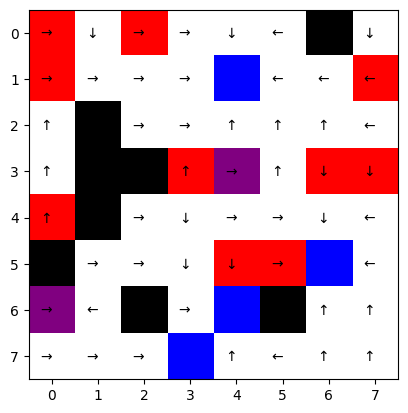

In [ ]:
pi = optimal_policy(env, fin_v, 1.0)
draw_policy(env, pi)

Policy iteration - using V-function

In [ ]:
def policy_evaluation(env, policy, gamma, eps=1e-4, maxiter=1000):
    states = env.get_states()
    V = {s: 0.0 for s in states}

    for _ in range(maxiter):
        delta = 0
        for s in states:
            if env.is_terminal(s):
                continue
            a = policy[s]
            next_s, reward, done = env(s, a)
            v_new = reward + gamma * V[next_s]
            delta = max(delta, abs(v_new - V[s]))
            V[s] = v_new
        if delta < eps:
            break
    return V

In [ ]:
def policy_improvement(env, V, gamma, old_policy):
    policy_stable = True
    policy = {}
    actions = env.get_actions()

    for s in env.get_states():
        if env.is_terminal(s):
            policy[s] = None
            continue

        old_action = old_policy.get(s, None)

        best_action = max(actions, key=lambda a: env(s, a)[1] + gamma * V[env(s, a)[0]])
        policy[s] = best_action
        if old_action != best_action:
            policy_stable = False

    return policy, policy_stable

In [ ]:
def policy_iteration_v(env, gamma=1.0, eps=1e-4, maxiter=100):

    actions = env.get_actions()
    policy = {s: actions[0] for s in env.get_states() if not env.is_terminal(s)}
    for s in env.get_states():
        if env.is_terminal(s):
            policy[s] = None

    for i in range(maxiter):
        V = policy_evaluation(env, policy, gamma, eps)
        policy, stable = policy_improvement(env, V, gamma, policy)
        if stable:
            return policy, V, i+1
    return policy, V, maxiter

##Policy iteration - using Q-function

In [ ]:
def policy_evaluation_q(env, policy, gamma, eps=1e-4, maxiter=1000):
    states = env.get_states()
    actions = env.get_actions()
    Q = {(s, a): 0.0 for s in states for a in actions}

    for _ in range(maxiter):
        delta = 0
        for s in states:
            if env.is_terminal(s):
                for a in actions:
                    Q[(s, a)] = 0.0
                continue

            a = policy[s]
            next_s, reward, done = env(s, a)
            q_new = reward + gamma * max(Q[(next_s, a2)] for a2 in actions)
            delta = max(delta, abs(q_new - Q[(s, a)]))
            Q[(s, a)] = q_new
        if delta < eps:
            break
    return Q

In [ ]:
def policy_improvement_from_q(env, Q, old_policy):
    policy_stable = True
    policy = {}
    actions = env.get_actions()

    for s in env.get_states():
        if env.is_terminal(s):
            policy[s] = None
            continue

        old_action = old_policy.get(s, None)
        best_action = max(actions, key=lambda a: Q[(s, a)])
        policy[s] = best_action
        if old_action != best_action:
            policy_stable = False

    return policy, policy_stable

In [ ]:
def policy_iteration_q(env, gamma=1.0, eps=1e-4, maxiter=100):
    actions = env.get_actions()
    policy = {s: actions[0] for s in env.get_states() if not env.is_terminal(s)}
    for s in env.get_states():
        if env.is_terminal(s):
            policy[s] = None

    for i in range(maxiter):
        Q = policy_evaluation_q(env, policy, gamma, eps)
        policy, stable = policy_improvement_from_q(env, Q, policy)
        if stable:
            return policy, Q, i+1
    return policy, Q, maxiter

In [ ]:
policy_v, V, iter_v = policy_iteration_v(env)
print(f"Policy iteration with V converged in {iter_v} iterations.")

policy_q, Q, iter_q = policy_iteration_q(env)
print(f"Policy iteration with Q converged in {iter_q} iterations.")


Policy iteration with V converged in 100 iterations.
Policy iteration with Q converged in 100 iterations.


## Assignments for Individual Work (Level 1)

1. Add TELEPORT CELLS and modify the code to accomodate this kind of cells also.
2. Implement value iteration algorithm using Q function instead of V function.
3. Implement policy iteration algorithm using both V and Q functions.

In all cases update, modify, and add visualization facilities to illustrate correctness of the implementation.

## Assignments for Individual Work (Level 2)

1. Modify the code assuming that the maze is stochastic (so that a given action in a given cell may result with different outcomes with different known probabilities)
2. Repeat Level 1 assignments for this kind of maze.

## Assignments for Individual Work (Level 3)

1. Repeat Level 1 assignments assuming that the Maze is graph-like and not grid-like, so that there are different possible actions to take from each cell.

**Individual Work (Level 2)**

In [ ]:
class StochasticMazeEnvironment(MazeEnvironment):
    def __init__(self, board, success_prob=0.8):
        super().__init__(board)
        self.success_prob = success_prob

    def get_transitions(self, state, action):
        """
        Returns a list of tuples: (next_state, reward, is_terminal, probability)
        for all possible outcomes of an action.
        """
        if self.is_terminal(state):
            return []

        actions = self.get_actions() # [0, 1, 2, 3] -> [RIGHT, UP, LEFT, DOWN]
        slip_prob = (1.0 - self.success_prob) / (len(actions) - 1)

        transitions = []
        for a in actions:
            # Probability is success_prob if it's the intended action,
            # otherwise it's the slip_prob
            prob = self.success_prob if a == action else slip_prob

            # Reuse the deterministic logic to find where the agent ends up
            next_s, reward, done = super().__call__(state, a)
            transitions.append((next_s, reward, done, prob))

        return transitions

In [ ]:
def stochastic_q_iteration(env, gamma=1.0, eps=0.01, maxiter=100):
    states = env.get_states()
    actions = env.get_actions()

    # Initialize Q(s,a) with zeros
    Q = {(s, a): 0.0 for s in states for a in actions}

    for k in range(maxiter):
        new_Q = Q.copy()
        max_error = 0

        for s in states:
            if env.is_terminal(s):
                continue

            for a in actions:
                # Stochastic update: sum of (prob * (reward + gamma * V_next))
                expected_value = 0
                outcomes = env.get_transitions(s, a)

                for next_s, reward, done, prob in outcomes:
                    # V(next_s) = max_a' Q(next_s, a')
                    max_next_q = max([Q[(next_s, a_next)] for a_next in actions])
                    expected_value += prob * (reward + gamma * max_next_q)

                max_error = max(max_error, abs(Q[(s, a)] - expected_value))
                new_Q[(s, a)] = expected_value

        Q = new_Q
        if max_error < eps:
            print(f"Stochastic Q-Iteration converged after {k+1} iterations.")
            return Q

    return Q

In [ ]:
def stochastic_policy_evaluation(env, policy, gamma, eps=1e-4):
    states = env.get_states()
    V = {s: 0.0 for s in states}

    for _ in range(1000):
        delta = 0
        for s in states:
            if env.is_terminal(s): continue

            action = policy[s]
            new_v = 0
            # Sum over all possible outcomes of the policy's action
            for next_s, reward, done, prob in env.get_transitions(s, action):
                new_v += prob * (reward + gamma * V[next_s])

            delta = max(delta, abs(V[s] - new_v))
            V[s] = new_v
        if delta < eps: break
    return V

def stochastic_policy_iteration(env, gamma=1.0, maxiter=100):
    states = env.get_states()
    actions = env.get_actions()

    # Start with a random policy
    policy = {s: actions[0] for s in states if not env.is_terminal(s)}

    for i in range(maxiter):
        V = stochastic_policy_evaluation(env, policy, gamma)

        # Policy Improvement
        policy_stable = True
        for s in states:
            if env.is_terminal(s): continue

            old_action = policy[s]
            # Choose best action based on expected future value
            best_action = None
            best_val = -float('inf')

            for a in actions:
                val_a = sum(prob * (reward + gamma * V[next_s])
                            for next_s, reward, done, prob in env.get_transitions(s, a))
                if val_a > best_val:
                    best_val = val_a
                    best_action = a

            policy[s] = best_action
            if old_action != best_action:
                policy_stable = False

        if policy_stable:
            print(f"Stochastic Policy Iteration converged after {i+1} iterations.")
            return policy, V

    return policy, V

In [ ]:
def draw_policy_level2(env, policy, ax=None):
    ax = ax if ax is not None else plt.gca()
    draw_board(env.board, ax=ax)
    draw_teleports(env.board, ax=ax)
    for s, a in policy.items():
        # Only try to draw a symbol if there is a valid action (skip None/Terminal)
        if a is not None:
            ax.text(s[1]-0.25, s[0]+0.1, action_symbol(a), fontsize=15, fontweight='bold')

Stochastic Q-Iteration converged after 36 iterations.


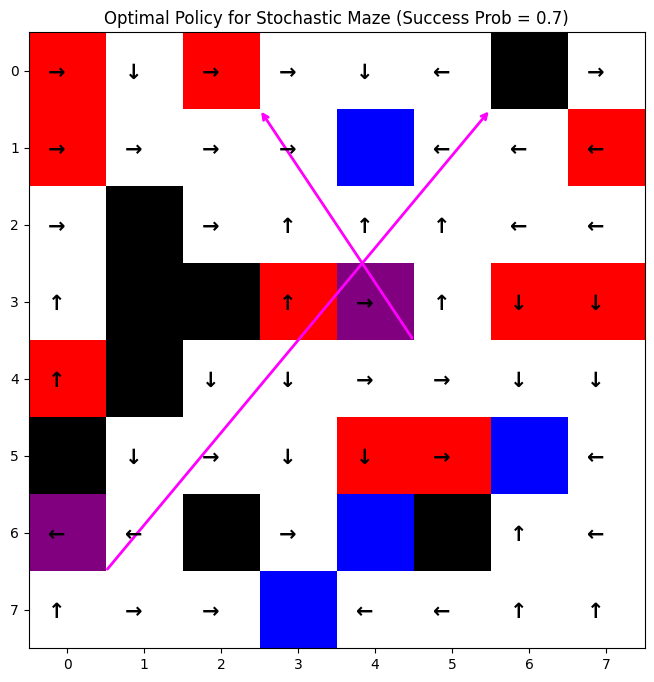

In [ ]:
stoch_env = StochasticMazeEnvironment(board, success_prob=0.8)

# level 2 using Q-Iteration
stoch_q_values = stochastic_q_iteration(stoch_env, gamma=0.9)

#  extract and draw policy
stoch_policy = extract_policy_from_q(stoch_q_values, stoch_env)

plt.figure(figsize=(8, 8))
draw_policy_level2(stoch_env, stoch_policy)
plt.title("Optimal Policy for Stochastic Maze (Success Prob = 0.7)")
plt.show()